In [42]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import sklearn.metrics as sk

In [28]:
# Load preprocessed dataset
dataset_file = np.load('final_augmented_dataset.npz')

X_train = dataset_file['X_train']
y_train = dataset_file['y_train']
X_val = dataset_file['X_val']
y_val = dataset_file['y_val']
X_test = dataset_file['X_test']
y_test = dataset_file['y_test']

# Verify Shapes
print(X_train.shape)
print(y_train.shape)

(22501, 5000, 1)
(22501, 3)


In [29]:
# Set parameters for model
initial_filters = 32
filters = 64
kernel_size = 7
pool_size = 2
units = 128
final_units = 3

# Build layers for model
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(initial_filters, kernel_size, activation='relu', input_shape=(X_train.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(pool_size),
    tf.keras.layers.Conv1D(filters, kernel_size, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size),
    tf.keras.layers.Conv1D(filters, kernel_size, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(units, activation='relu'),
    tf.keras.layers.Dense(final_units, activation='softmax')
])

# Verify model summary
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)              │ (None, 4994, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 2497, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 2491, 64)       │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 1245, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 1239, 64)       │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 619, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,099 (203.51 KB)

 Trainable params: 52,099 (203.51 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compile the model
model.compile('adam', 'categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), batch_size=32)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.6533 - loss: 0.7638 - val_accuracy: 0.8957 - val_loss: 0.3681
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.7423 - loss: 0.6156 - val_accuracy: 0.8043 - val_loss: 0.5759
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.7610 - loss: 0.5699 - val_accuracy: 0.8581 - val_loss: 0.4169
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 65ms/step - accuracy: 0.7733 - loss: 0.5434 - val_accuracy: 0.8462 - val_loss: 0.4674
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.7883 - loss: 0.5124 - val_accuracy: 0.8880 - val_loss: 0.3636
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.8024 - loss: 0.4855 - val_accuracy: 0.7470 - val_loss: 0.6660
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.8147 - loss: 0.4536 - val_accuracy: 0.8068 - val_loss: 0.5218
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.8274 - loss: 0.4239 - 

In [32]:
# Save model
model.save('ecg_model.keras')

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8959 - loss: 0.3310
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
              precision    recall  f1-score   support

        1AVB       0.39      0.71      0.51        76
        AFIB       0.87      0.65      0.74       148
        NORM       0.97      0.95      0.96       958

    accuracy                           0.90      1182
   macro avg       0.75      0.77      0.74      1182
weighted avg       0.92      0.90      0.90      1182



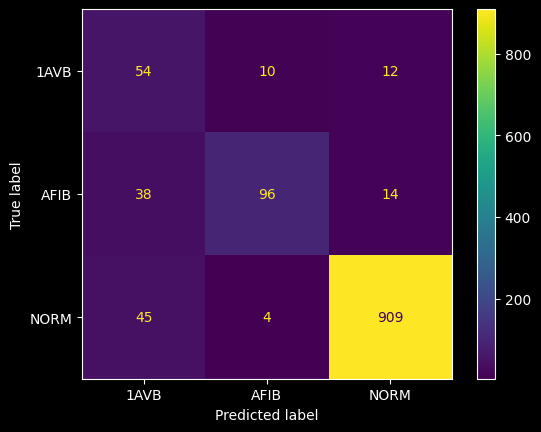

In [47]:
# Evaluate model
model.evaluate(X_test, y_test)

# Convert labels to integers
y_train_int = np.argmax(y_train, axis=1)
y_test_int = np.argmax(y_test, axis=1)

# Convert prediction labels to integers
predictions = model.predict(X_test)
predictions_int = np.argmax(predictions, axis=1)

# Print classification report
print(sk.classification_report(y_test_int, predictions_int, target_names= ['1AVB', 'AFIB', 'NORM']))

# Visualize confusion matrix
matrix = sk.ConfusionMatrixDisplay(confusion_matrix=sk.confusion_matrix(y_test_int, predictions_int), display_labels=['1AVB', 'AFIB', 'NORM']).plot()